![logo](https://climate.copernicus.eu/sites/default/files/2025-03/logoline_c3s.png)

# Tutorial on comparing CARRA and ERA5 2m temperature data 


**This notebook can be run on free online platforms, such as Binder, Kaggle and Colab, or they can be accessed from GitHub. The links to run this notebook in these environments are provided here, but please note they are not supported by ECMWF.**

[![binder](https://mybinder.org/badge.svg)](https://mybinder.org/v2/gh/ecmwf-training/c3s-training-submodule-reanalysis/develop?labpath=reanalysis-carra-era5.ipynb)
[![kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra-era5.ipynb)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra-era5.ipynb)
[![github](https://img.shields.io/badge/Open%20in-GitHub-black?logo=github)](https://github.com/ecmwf-training/c3s-training-submodule-reanalysis/blob/develop/reanalysis-carra-era5.ipynb)

## Introduction

Understanding global and regional atmospheric conditions is critical for climate research, weather forecasting, and environmental monitoring. Reanalysis datasets like ERA5 (ECMWF's fifth-generation global reanalysis) and CARRA (Copernicus Arctic Regional Reanalysis) provide high-quality, gridded estimates of atmospheric variables, enabling scientists to study past weather and climate patterns. Both datasets can be found in, and are freely accessible through, the [Copernicus Climate Data Store (CDS)](https://cds.climate.copernicus.eu/#!/home).

Both datasets enhance our insights into Earth's systems, but they are different in several aspects. ERA5 offers a comprehensive global perspective with a resolution of approximately 31 km. Meanwhile CARRA is regional and tailored for the Arctic region, delivering higher spatial resolution (~2.5 km) and specialized insights into polar processes, that make it particularly adequate for studying the Arctic’s unique climate dynamics.

In this tutorial, we focus on comparing 2m temperature data from both datasets. There are 5 CARRA entries available in the CDS: sub-daily data for [single](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-single-levels?tab=overview), [height](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-height-levels?tab=overview), [pressure](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-pressure-levels?tab=overview) and [model levels](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-model-levels?tab=overview) and data aggregated for a [day or month](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-means?tab=overview). Practical details of the CARRA dataset are available in [the documentation](https://confluence.ecmwf.int/x/K0s7E). Meanwhile, the complete ERA5 portfolio of datasets is availble at [ERA5](https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-complete?tab=overview).

Here the CARRA single level entry is selected for the 2m temperature. The ERA5 dataset, available in full via the Copernicus Climate Data Store (CDS), serves as our global benchmark. By comparing these datasets, you will get an awareness of their strengths, limitations, and potential applications — whether for validating regional models, assessing climate trends, or supporting decision-making in Arctic-sensitive sectors.


## Learning objectives 🎯

This tutorial demonstrates how to access and retrieve CARRA and ERA5 data and how to inter-compare them on the CARRA domain. CARRA is a high resolution (2.5 km) regional re-analysis which gives added details compared to the ERA5 global reanalysis. These details can be visualised by comparing the plots of CARRA and ERA5 data, and particularly when the differences of the two datasets are plotted together. By the end, you will have:
- Accessed and downloaded 2m temperature data from both the ERA5 and CARRA data, interacting with the Copernicus Climate Data Store using Python code.
- Prepared the data for an inter-comparison, by interpolating them to the same grid and computing monthly means.
- Created engaging map-like visuals (plots), that emphasize the differences between the two datasets.


## Prepare your environment

### Install earthkit and cdsapi

We will request data from the Climate Data Store (CDS) with the help of [earthkit](https://earthkit-data.readthedocs.io/en/latest/).

The code below will ensure that the `earthkit` and `cdsapi` packages are installed.  earthkit-data's `cds` source uses the `cdsapi` package under the hood to talk to the CDS, so `cdsapi` needs to be installed too, even though we never import or call it directly.

In [ ]:
%pip install -q cdsapi earthkit

### (Install and) Import libraries

To run the code in this tutorial please install any missing packages here.


*Please note that the package xESMF is not in the environment file, but can be installed following the instructions [here](https://xesmf.readthedocs.io/en/stable/).*


In [1]:
import warnings
import cartopy.crs as ccrs

# earthkit for dowloading and transforming data and for plotting
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.utils.units.convert import convert_units

# Package to interpolate ERA5 data to the CARRA grid
import xesmf as xe

warnings.filterwarnings('ignore') #turn off some warnings


### Specify the period to plot


In [2]:
period = "202403" # the period to plot

## Explore data

To search for data, visit the CDS website: https://cds.climate.copernicus.eu.
Here you can search for CARRA data using the search bar. The data we need for this tutorial is the [Arctic regional reanalysis on single levels from 1991 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-carra-single-levels?tab=overview).

´earthkit-data´ will retrieve a specific month directly into memory (with local caching, so re-running a cell does not re-download). By specifying the start and end date below, one can easily download longer periods. We are selecting 2m temperature, which is in the single level CDS entry.
Here, we request the 3-hourly analysis time steps.

For this tutorial we just request one month of data, March 2024. Note that we define a sub-domain to use for the ERA5 request.


In [3]:
# Here one specifies the domain, year and period to download

yearStart = 2024 #first year to download
yearEnd   = 2024 #last year to download
monthStart =  3 # first month to download
monthEnd   =  3 #last month to download
days = [str(i).zfill(2) for i in range(1,31)] # the list of days to download. Adapt day number for other months
domain = 'west_domain' # the domain to select. Use "east_domain" for the CARRA-East domain
period="202403" # the period to plot

# Below a polygon to limit the area downloaded from ERA5, otherwise it will download the whole world
area_for_era5 = [90, -110, 55, 40] #WEST domain polygon, format: North,West,South,East corners
#area_for_era5 = [85,0,60,50]: EAST domain polygon

### Download the data

If you have not set up your .cdsapirc file, you will be prompted for your CDS credentials when executing the download cell. See [how to api](https://cds.climate.copernicus.eu/how-to-api) for details on how to set up your .cdsapirc file.

#### Define helper functions to formulate the CDS data request

The functions below allow repeated CDS API requests to be made with earthkit-data, in case multiple requests are required to retrieve high volumes of data. In this case we are only requesting one month.


In [4]:
# Define a helper function to retrieve CARRA data.
# Note that the time is hardcoded since we are selecting
# all possible available times.
def fetch_month_carra(month, year, days, domain):
    return ekd.from_source(
        "cds",
        "reanalysis-carra-single-levels",
        {
            'data_format': 'grib',
            'domain': domain,
            'level_type': 'surface_or_atmosphere',
            'variable': '2m_temperature',
            'product_type': 'analysis',
            'year': str(year),
            'month': str(month).zfill(2),
            'day': days,
            'time': [
                '00:00', '03:00', '06:00',
                '09:00', '12:00', '15:00',
                '18:00', '21:00',
            ],
        })

# Helper function to retrieve ERA5 data
def fetch_month_era5(month, year, days, area):
    return ekd.from_source(
        "cds",
        "reanalysis-era5-single-levels",
        {
            'product_type': 'reanalysis',
            'variable': '2m_temperature',
            'year': str(year),
            'month': str(month).zfill(2),
            'day': days,
            'time': [
                '00:00', '03:00', '06:00',
                '09:00', '12:00', '15:00',
                '18:00', '21:00',
            ],
            'area': area,
            'data_format': 'grib',
        })


#### Retrieve the CARRA-West data

The loop below may be useful if you are requesting a large volume of data; in this example only 2024-03 is requested. Successive months are simply concatenated with `+`.


In [5]:
# Loop through the period selected (in this example only 2024 03 is requested)
carra_data = None
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("CARRA data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (here ~621 MB for west, ~357 MB for east case)")
        month_data = fetch_month_carra(month, year, days, domain)
        carra_data = month_data if carra_data is None else carra_data + month_data


CARRA data will be fetched for  2024 3
This will take a few minutes, depending on the data size (here ~621 MB for west, ~357 MB for east case)


2026-09-24 15:58:14,406 INFO Request ID is c2f27250-2546-42f7-8d88-0ce208920d8f
2026-09-24 15:58:14,493 INFO status has been updated to successful


ddb424530eb131fa18e3b4fba1db985e.grib:   0%|          | 0.00/621M [00:00<?, ?B/s]

#### Retrieve the ERA5 data


In [6]:
# Loop through the period selected
era5_data = None
for year in list(range(yearStart, yearEnd + 1)):
    for month in list(range(1,13)):
        if year == yearStart and month < monthStart:
            # Before the start date.
            continue
        if year == yearEnd and month > monthEnd:
            # After end date.
            break

        print ("ERA5 data will be fetched for ", year, month)
        print("This will take a few minutes, depending on the data size (here ~39 MB for west area)")
        month_data = fetch_month_era5(month, year, days, area_for_era5)
        era5_data = month_data if era5_data is None else era5_data + month_data


ERA5 data will be fetched for  2024 3
This will take a few minutes, depending on the data size (here ~39 MB for west area)


2026-09-24 15:59:51,297 INFO Request ID is cc38d9b1-b3a0-424f-975f-ebdbfa290d5d
2026-09-24 15:59:51,383 INFO status has been updated to successful


469aa520326dd4b5b9fe3eed7a67d967.grib:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

## Plotting the CARRA and ERA5 data


### Interpolate data to a common grid
Before plotting the two datasets we want to have them on the same grid. For this we interpolate ERA5 to the CARRA (CARRA-West) grid.
We then convert the retrieved data to Xarray, transform Kelvin to Celsius, and inspect the ERA5 datacube.

In [7]:
def _normalize_grib_dataset(ds):
    # CARRA/ERA5 GRIB can decode with different variable and dimension names
    # depending on the eccodes/cfgrib version and product type in use:
    #  - the 2m temperature variable can come back as "t2m" (cfVarName) or
    #    "2t" (WMO short name)
    #  - CARRA is retrieved with a leadtime (product_type "analysis"), so
    #    cfgrib can index it on "forecast_reference_time" instead of "time"
    # Normalise both so the rest of this notebook can consistently use
    # "t2m" and "time".
    if 't2m' not in ds.data_vars and '2t' in ds.data_vars:
        ds = ds.rename({'2t': 't2m'})
    if 'time' not in ds.dims:
        for alt in ('forecast_reference_time', 'valid_time'):
            if alt in ds.dims:
                ds = ds.rename({alt: 'time'})
                break
    return ds

ERA5 = _normalize_grib_dataset(era5_data.to_xarray())
ERA5 = convert_units(ERA5,'degC','K')
ERA5


<xarray.Dataset> Size: 163MB
Dimensions:    (time: 240, latitude: 141, longitude: 601)
Coordinates:
  * time       (time) datetime64[us] 2kB 2024-03-01 ... 2024-03-30T21:00:00
  * latitude   (latitude) float64 1kB 90.0 89.75 89.5 89.25 ... 55.5 55.25 55.0
  * longitude  (longitude) float64 5kB -110.0 -109.8 -109.5 ... 39.5 39.75 40.0
Data variables:
    t2m        (time, latitude, longitude) float64 163MB -27.61 -27.61 ... 7.161
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Transform Kelvin to Celsius and inspect the CARRA datacube.


In [8]:
CARRA = _normalize_grib_dataset(carra_data.to_xarray())
CARRA = convert_units(CARRA,'degC','K')
CARRA

'Grid' object has no attribute 'to_distinct_latlon'
Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)


ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])


<xarray.Dataset> Size: 3GB
Dimensions:    (time: 240, y: 1269, x: 1069)
Coordinates:
  * time       (time) datetime64[us] 2kB 2024-03-01 ... 2024-03-30T21:00:00
    latitude   (y, x) float64 11MB ...
    longitude  (y, x) float64 11MB ...
Dimensions without coordinates: y, x
Data variables:
    t2m        (time, y, x) float64 3GB -5.837 -5.774 -5.679 ... -23.36 -23.28
Attributes:
    Conventions:  CF-1.8
    institution:  ECMWF

Before going further, let's use earthkit-plots for a quick look at a single CARRA timestep.


Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)
Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)


ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])
ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])


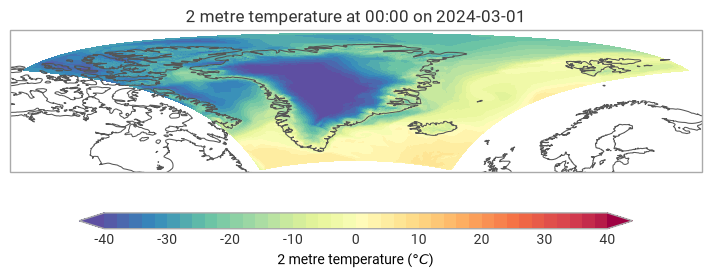

In [9]:
ekp.quickplot(CARRA['t2m'].isel(time=0))

Now use xesmf bilinear interpolation to construct a regridder object and apply it to the ERA5 data.

In [10]:
# Create regridder using xesmf bilinear interpolation
regridder = xe.Regridder(ERA5, CARRA, "bilinear")
# Regrid the data
print("regridding the ERA5 data")
ERA5_CARRA = regridder(ERA5)
print("done")

regridding the ERA5 data
done


Check the format of the output. Since earthkit-data and xesmf keep everything in memory, there is no need to write the regridded data back out to disk before using it in the next step (though you could still call `ERA5_CARRA.to_netcdf(...)` if you wanted to cache it).


In [11]:
ERA5_CARRA

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 240, y: 1269, x: 1069)
Coordinates:
  * time       (time) datetime64[us] 2kB 2024-03-01 ... 2024-03-30T21:00:00
    latitude   (y, x) float64 11MB 55.81 55.82 55.82 55.83 ... 77.87 77.85 77.82
    longitude  (y, x) float64 11MB 302.9 302.9 303.0 303.0 ... 37.66 37.7 37.73
Dimensions without coordinates: y, x
Data variables:
    t2m        (time, y, x) float64 3GB -5.389 -5.261 -5.133 ... -22.24 -22.21
Attributes:
    regrid_method:  bilinear

### Plotting the data
Compute the mean 2m temperature over the whole month. We already have `CARRA` and the regridded `ERA5_CARRA` in memory, so we just calculate their mean over the whole month, and prepare the dataset for plotting on a latitude/longitude grid.


In [12]:
# Compute monthly mean
print("Computing the mean for CARRA and ERA5...")
CARRA_mean = ekt.temporal.monthly_mean(CARRA)
ERA5_mean = ekt.temporal.monthly_mean(ERA5_CARRA)
print("Done.")

# Change longitudes from 0-360 to -180 to 180, needed for the plotting
CARRA_mean = CARRA_mean.assign_coords(longitude=(((CARRA_mean.longitude + 180) % 360) - 180))
ERA5_mean = ERA5_mean.assign_coords(longitude=CARRA_mean.longitude)

Computing the mean for CARRA and ERA5...
Done.


In [13]:
ERA5_mean

<xarray.Dataset> Size: 33MB
Dimensions:    (time: 1, y: 1269, x: 1069)
Coordinates:
  * time       (time) datetime64[us] 8B 2024-03-01
    latitude   (y, x) float64 11MB 55.81 55.82 55.82 55.83 ... 77.87 77.85 77.82
    longitude  (y, x) float64 11MB -57.1 -57.06 -57.02 ... 37.66 37.7 37.73
Dimensions without coordinates: y, x
Data variables:
    t2m        (time, y, x) float64 11MB -4.437 -4.327 -4.217 ... -15.7 -15.65
Attributes:
    regrid_method:  bilinear

#### Plot for CARRA

We fix the scale of each of the separate CARRA and ERA5 plots to the range from -30 to 30 degrees Celsius. This ensures the two figures can be compared directly. 

The plot below shows the CARRA 2m temperature monthly mean (March 2024) values for the CARRA-West domain.

Plotting CARRA mean surface temperature
Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)
Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)


ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])
ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])


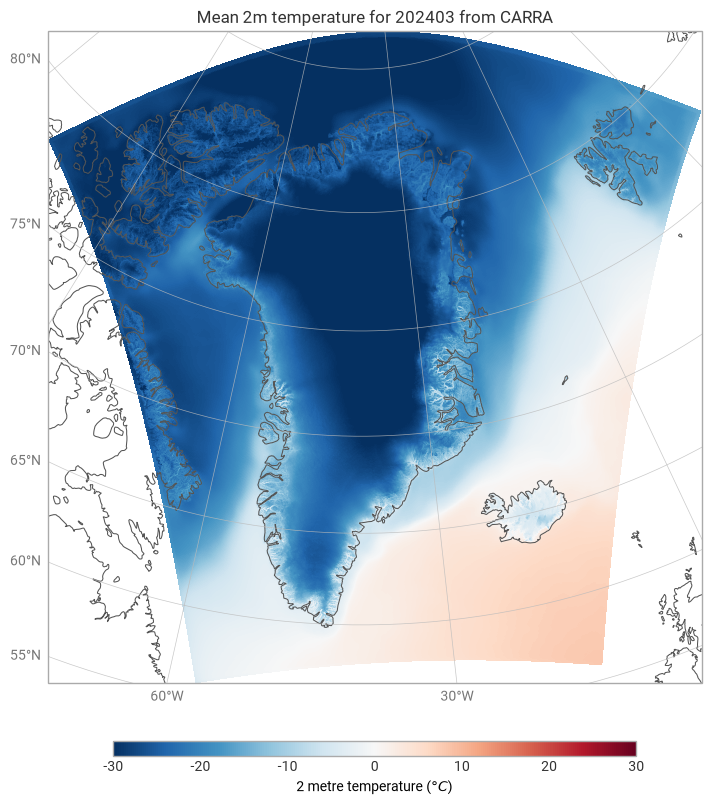

In [14]:
print("Plotting CARRA mean surface temperature")
map = ekp.Map(crs=ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0))
map.pcolormesh(
    CARRA_mean.t2m,
    x="longitude",
    y="latitude",
    colors="RdBu_r",
    vmin=-30,
    vmax=30,
)
map.title(f"Mean 2m temperature for {period} from CARRA")
map.coastlines()
map.gridlines()
map.legend()
map.show()


#### Plot for ERA5

The plot shows ERA5 2m temperature monthly mean (March 2024) values on the CARRA-West domain. 

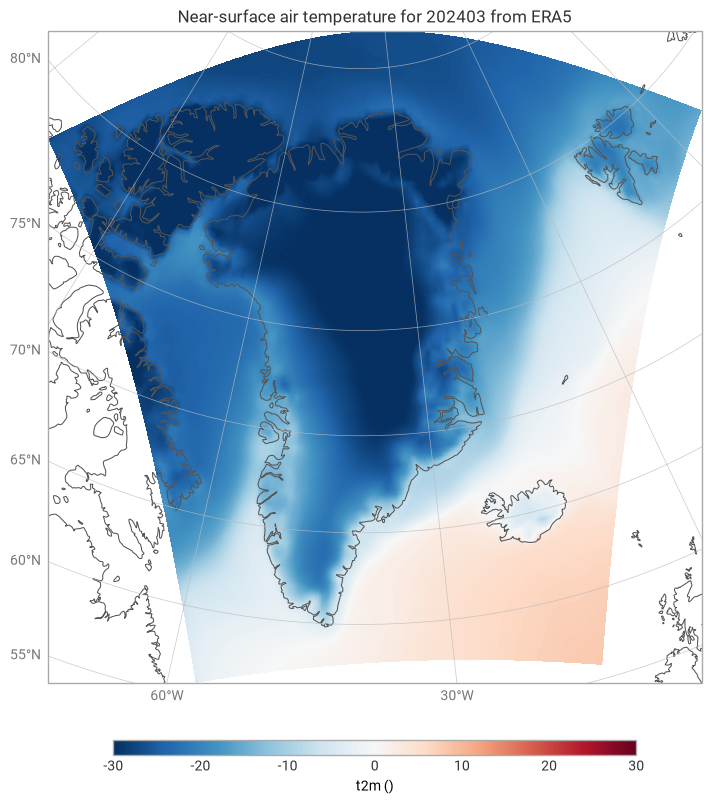

In [15]:
map = ekp.Map(crs=ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0))
map.pcolormesh(
    ERA5_mean.t2m,
    x="longitude",
    y="latitude",
    colors="RdBu_r",
    vmin=-30,
    vmax=30,
)
map.title(f"Near-surface air temperature for {period} from ERA5")
map.coastlines()
map.gridlines()
map.legend()
map.show()

#### Plot the difference between CARRA and ERA5

Note that the differences are computed in the plotting command itself. Here we plot the difference with a range of -10 to 10 degrees Celsius.

The plot shows the 2m monthly mean (March 2024) 2m temperature difference between CARRA and ERA5 over the CARRA-West domain.

Plotting the difference CARRA - ERA5
Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)
Exception: SpecError: ['grid' = ['dx', 'dy'] must be positive]  (/tmp/cxx-build/src/eckit/src/eckit/geo/grid/regular/RegularXY.cc:30 Increments)


ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])
ECCODES ERROR   :  GridSpec: Exception thrown (SpecError: ['grid' = ['dx', 'dy'] must be positive])


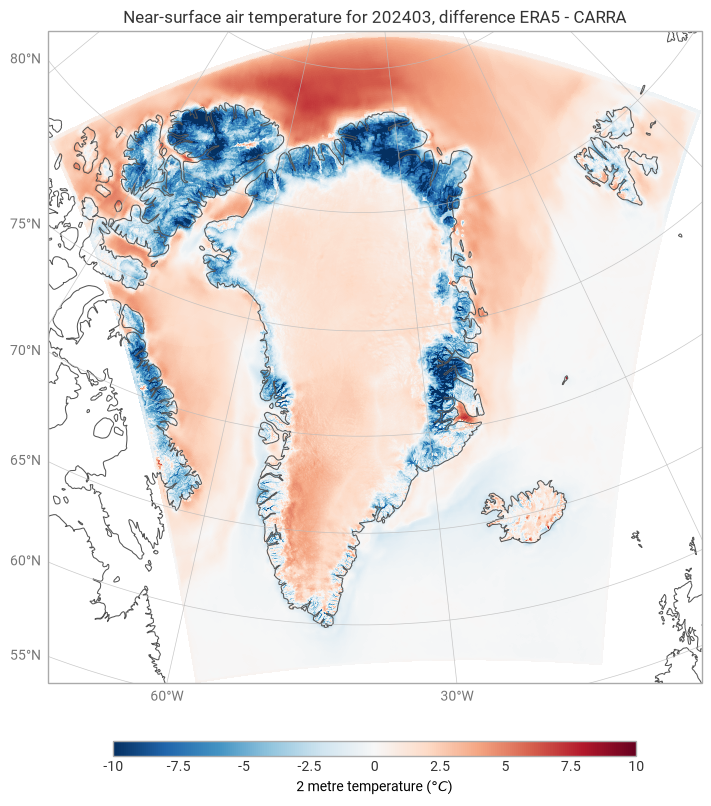

In [16]:
print("Plotting the difference CARRA - ERA5")

map = ekp.Map(crs=ccrs.LambertConformal(central_latitude=70.0, central_longitude=-40.0))
map.pcolormesh(
    ERA5_mean.t2m - CARRA_mean.t2m,
    x="longitude",
    y="latitude",
    colors="RdBu_r",
    vmin=-10,
    vmax=10,
)
map.title(f"Near-surface air temperature for {period}, difference ERA5 - CARRA")
map.coastlines()
map.gridlines()
map.legend()
map.show()

## Take home messages 📌

- CARRA and ERA5 data, while broadly similar, contain subtle, but important differences in values due to their spatial scope. These differences are important to note.

- Note the differences visible between CARRA and ERA5, especially over coastal areas and over complex orography (mountainous terrain) where the high resolution CARRA data can provide additional information compared to ERA5, such as for instance the significantly lower temperatures at higher elevations near the coasts.

- The differences in northern ocean areas likely come from the better description of sea-ice characteristics by CARRA. 

- The differences are much easier to see in the difference plot above, however they can also be recognised in the individual plots as finer details in the CARRA plot.